In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install torch torchvision tqdm

### Data load

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import torch
import scipy.io

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import datasets, transforms, models
from torchvision import transforms

In [4]:
data_path = "/content/drive/MyDrive/Flower_classification/"

labels_mat = scipy.io.loadmat(os.path.join(data_path, "imagelabels.mat"))
split_mat  = scipy.io.loadmat(os.path.join(data_path, "setid.mat"))

labels = labels_mat["labels"][0]

train_ids = split_mat["trnid"][0]
val_ids   = split_mat["valid"][0]
test_ids  = split_mat["tstid"][0]

### Data Transforms

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [6]:
class FlowerDataset(Dataset):

    def __init__(self, image_ids, labels, image_dir, transform=None):
        self.image_ids = image_ids
        self.labels = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        img_name = f"image_{image_id:05d}.jpg"
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = self.labels[image_id - 1] - 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
image_dir = os.path.join(data_path, "102flowers/jpg")

train_dataset = FlowerDataset(train_ids, labels, image_dir, transform)
val_dataset   = FlowerDataset(val_ids, labels, image_dir, transform)
test_dataset  = FlowerDataset(test_ids, labels, image_dir, transform)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([ 5, 59, 91, 99, 50, 32, 43, 87, 29, 52], dtype=torch.uint8)


In [10]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1020
Validation: 1020
Test: 6149


### Load Pretrained ResNet50

In [11]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


### Freeze Feature Layers

In [12]:
for param in model.parameters():
    param.requires_grad = False

### Replace Final Layer

In [13]:
model.fc = nn.Linear(model.fc.in_features, 102)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

### Loss and Optimizer

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

### Training Loop

In [16]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(train_loader))

100%|██████████| 32/32 [11:11<00:00, 20.97s/it]


Epoch: 1 Loss: 4.627530038356781


100%|██████████| 32/32 [04:56<00:00,  9.27s/it]


Epoch: 2 Loss: 2.6099223867058754


100%|██████████| 32/32 [04:49<00:00,  9.04s/it]


Epoch: 3 Loss: 1.552889060229063


100%|██████████| 32/32 [04:58<00:00,  9.31s/it]


Epoch: 4 Loss: 0.9772525243461132


100%|██████████| 32/32 [04:50<00:00,  9.08s/it]

Epoch: 5 Loss: 0.6581634851172566


### Validation Accuracy

In [17]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 78.62745098039215


### Test Accuracy

In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test accuracy:",100*correct/total)

Test accuracy: 74.74386079037242


### Visualize Predictions

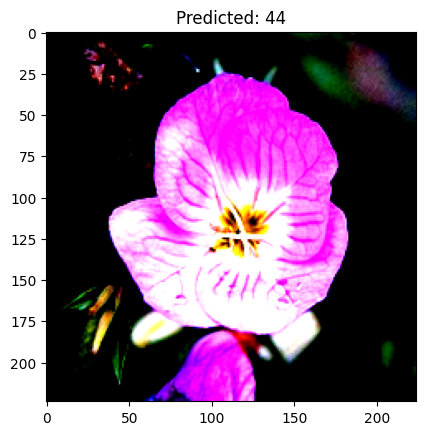

In [19]:
images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs,1)

plt.imshow(images[0].cpu().permute(1,2,0))
plt.title(f"Predicted: {preds[0]}")
plt.show()

In [20]:
torch.save(model.state_dict(), "flower_resnet50.pth")